In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

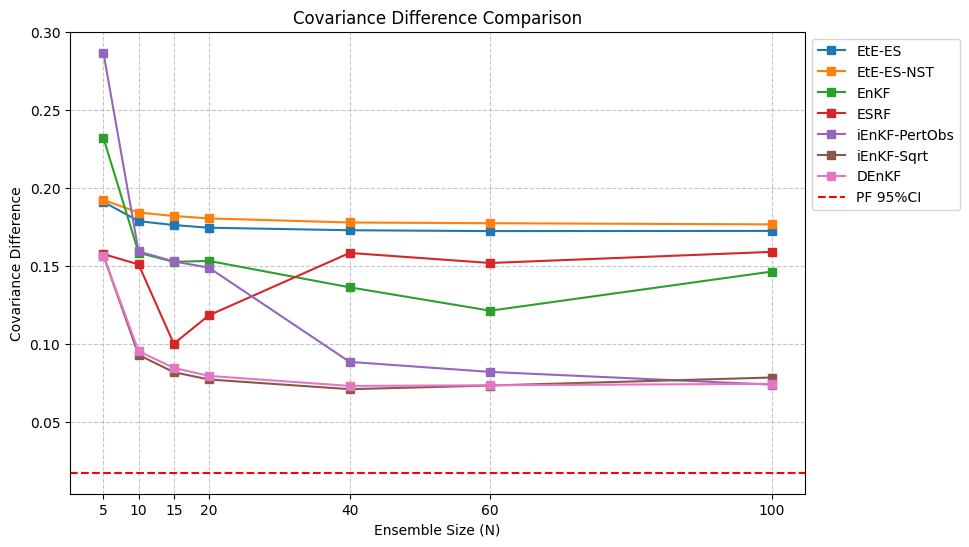

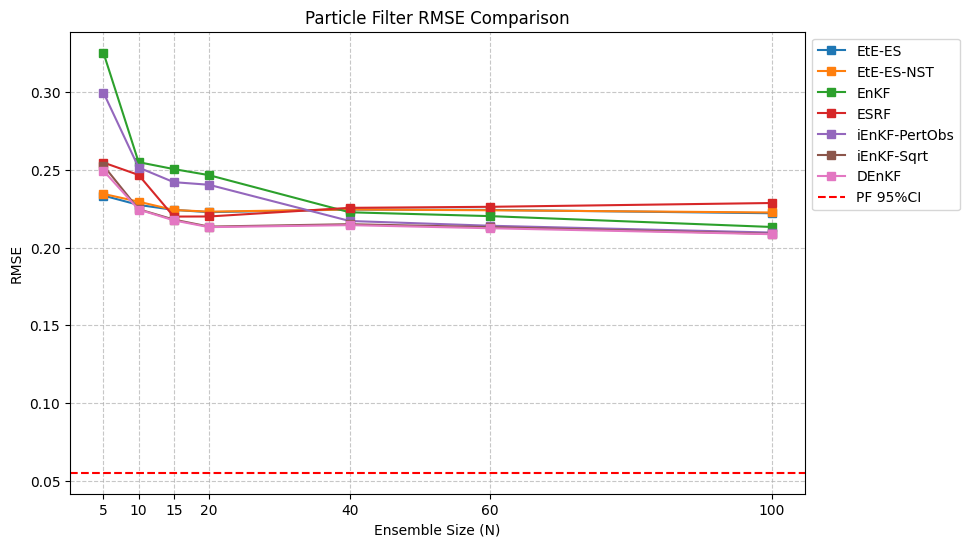

In [5]:
import os
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# --- [DATA LOADING AND PREPARATION - UNCHANGED] ---
PF_Cov_Diff_95CI = 0.0174
PF_RMSE_95CI = 0.0551
ensemble_sizes = [5, 10, 15, 20, 40, 60, 100]

data_folders = [
    "rossler_EtE_LRes/2025-08-06_10-19rossler_1.0_10_60_8192_es_joint_EtE-LRes",
    "rossler_EtE_LRes/2025-08-06_10-19rossler_1.0_10_60_8192_es_joint_EtE-LRes_nst",
    "rossler_benchmarks/benchmark_rossler_1.0_EnKF",
    "rossler_benchmarks/benchmark_rossler_1.0_ESRF",
    "rossler_benchmarks/benchmark_rossler_1.0_iEnKS-PertObs",
    "rossler_benchmarks/benchmark_rossler_1.0_iEnKS-Sqrt",
    "rossler_benchmarks/benchmark_rossler_1.0_iEnKS-Order1", 
]

method_names = [
            'EtE-ES', 
            'EtE-ES-NST',
            "EnKF",
            "ESRF",
            "iEnKF-PertObs",
            "iEnKF-Sqrt",
            "DEnKF", # A deterministic formulation of the ensemble Kalman filter: an alternative to ensemble square root filters
            ]
results = {}

num_sizes = len(ensemble_sizes)
for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}.pt"
        
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)
        data = torch.load(data_file, weights_only=True)
        cov_diff = data["nn"]['cov_diff']
        pf_rmse = data["nn"]['pf_rmse']

        results.setdefault(method_name, {})
        results[method_name].setdefault('cov_diff', [])
        results[method_name].setdefault('pf_rmse', [])
        results[method_name]['cov_diff'].append(cov_diff)
        results[method_name]['pf_rmse'].append(pf_rmse)
# --- [END OF UNCHANGED SECTION] ---


# --- Figure 1: Covariance Difference ---
fig1, ax1 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax1.plot(ensemble_sizes, results[key]['cov_diff'], marker='s', label=key)
ax1.axhline(y=PF_Cov_Diff_95CI, color='r', linestyle='--', label='PF 95%CI')
ax1.set_title('Covariance Difference Comparison')
ax1.set_xlabel('Ensemble Size (N)')
ax1.set_ylabel('Covariance Difference')
ax1.set_xticks(ensemble_sizes)
ax1.grid(True, linestyle='--', alpha=0.7)

# Place legend outside the plot area to the upper right
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
# Adjust subplot to prevent legend from being cut off
fig1.subplots_adjust(right=0.65)

# --- Inset for Figure 2 ---
# axins = ax1.inset_axes([0.45, 0.4, 0.5, 0.5])
# for key in results.keys():
#     axins.plot(ensemble_sizes, results[key]['cov_diff'], marker='s')
# axins.axhline(y=PF_Cov_Diff_95CI, color='r', linestyle='--')

# x1, x2, y1, y2 = 0, 22, 0.5, 0.7
# axins.set_xlim(x1, x2)
# axins.set_ylim(y1, y2)
# axins.grid(True, linestyle='--', alpha=0.6)
# mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5")



# --- Figure 2: Particle Filter RMSE ---
fig2, ax2 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax2.plot(ensemble_sizes, results[key]['pf_rmse'], marker='s', label=key)
ax2.axhline(y=PF_RMSE_95CI, color='r', linestyle='--', label='PF 95%CI')
ax2.set_title('Particle Filter RMSE Comparison')
ax2.set_xlabel('Ensemble Size (N)')
ax2.set_ylabel('RMSE')
ax2.set_xticks(ensemble_sizes)
ax2.grid(True, linestyle='--', alpha=0.7)

# Place legend outside the plot area to the upper right
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
# Adjust subplot to prevent legend from being cut off
fig2.subplots_adjust(right=0.65)


# --- Inset for Figure 2 ---
# axins = ax2.inset_axes([0.45, 0.4, 0.5, 0.5])
# for key in results.keys():
#     axins.plot(ensemble_sizes, results[key]['pf_rmse'], marker='s')
# axins.axhline(y=PF_RMSE_95CI, color='r', linestyle='--')

# x1, x2, y1, y2 = 0, 22, 0.5, 0.6
# axins.set_xlim(x1, x2)
# axins.set_ylim(y1, y2)
# axins.grid(True, linestyle='--', alpha=0.6)
# mark_inset(ax2, axins, loc1=2, loc2=4, fc="none", ec="0.5")


# Show both plots
plt.show()

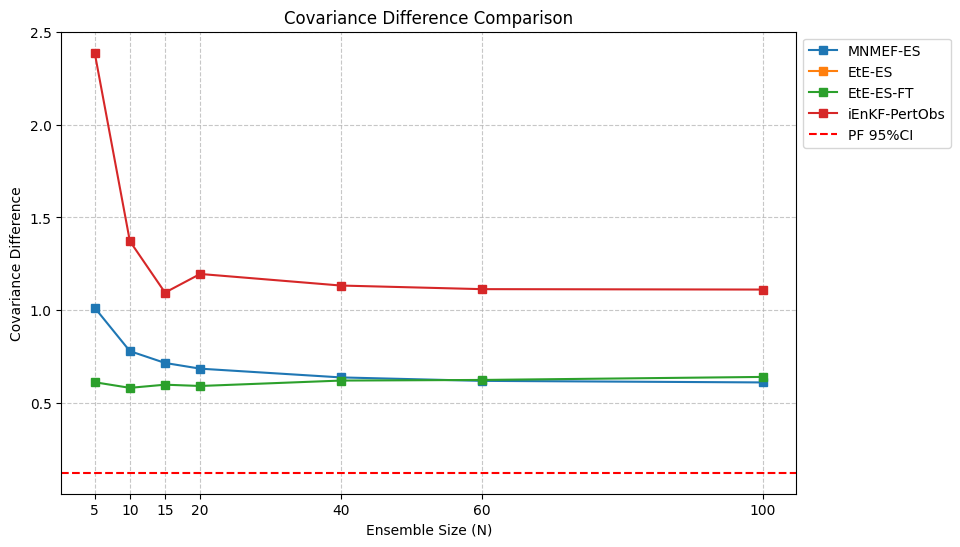

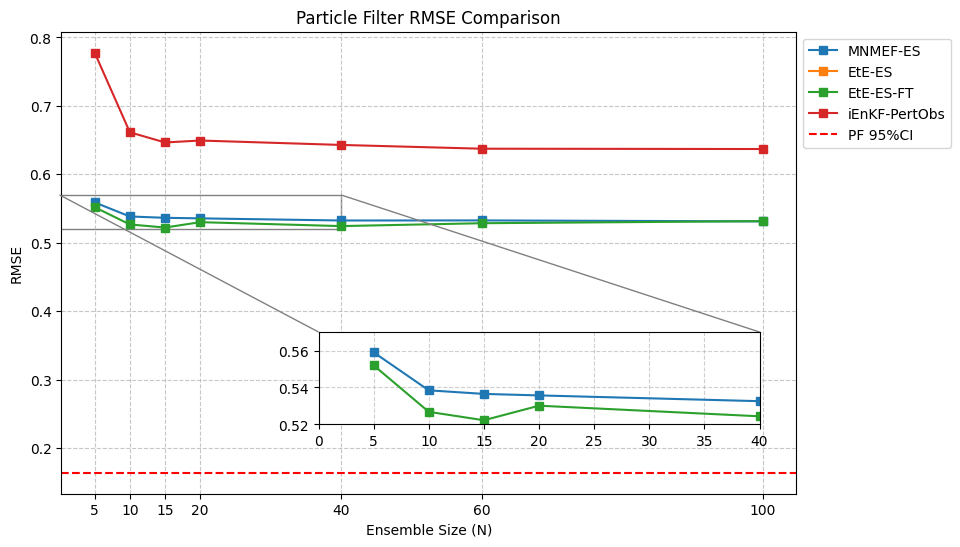

In [4]:
import os
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# --- [DATA LOADING AND PREPARATION - UNCHANGED] ---
PF_Cov_Diff_95CI = 0.122
PF_RMSE_95CI = 0.164
ensemble_sizes = [5, 10, 15, 20, 40, 60, 100]

data_folders = [
    "2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
    "lorenz63_EtE_LRes/2025-07-09_19-08lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nst",
    "lorenz63_EtE_LRes/2025-08-07_11-00lorenz63_1.0_20_60_8192_nl2_joint_EtE-LRes_tuned",
    "lorenz63_benchmarks/benchmark_lorenz63_1.0_iEnKS-PertObs",
]

method_names = ['MNMEF-ES',
            'EtE-ES', # always nst
            'EtE-ES-FT',
            "iEnKF-PertObs",
            ]
results = {}

num_sizes = len(ensemble_sizes)
for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}.pt"
        
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)
        data = torch.load(data_file, weights_only=True)
        cov_diff = data["nn"]['cov_diff']
        pf_rmse = data["nn"]['pf_rmse']

        results.setdefault(method_name, {})
        results[method_name].setdefault('cov_diff', [])
        results[method_name].setdefault('pf_rmse', [])
        results[method_name]['cov_diff'].append(cov_diff)
        results[method_name]['pf_rmse'].append(pf_rmse)
# --- [END OF UNCHANGED SECTION] ---


# --- Figure 1: Covariance Difference ---
fig1, ax1 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax1.plot(ensemble_sizes, results[key]['cov_diff'], marker='s', label=key)
ax1.axhline(y=PF_Cov_Diff_95CI, color='r', linestyle='--', label='PF 95%CI')
ax1.set_title('Covariance Difference Comparison')
ax1.set_xlabel('Ensemble Size (N)')
ax1.set_ylabel('Covariance Difference')
ax1.set_xticks(ensemble_sizes)
ax1.grid(True, linestyle='--', alpha=0.7)

# Place legend outside the plot area to the upper right
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
# Adjust subplot to prevent legend from being cut off
fig1.subplots_adjust(right=0.65)

# --- Inset for Figure 2 ---
# axins = ax1.inset_axes([0.45, 0.4, 0.5, 0.5])
# for key in results.keys():
#     axins.plot(ensemble_sizes, results[key]['cov_diff'], marker='s')
# axins.axhline(y=PF_Cov_Diff_95CI, color='r', linestyle='--')

# x1, x2, y1, y2 = 0, 22, 0.5, 0.7
# axins.set_xlim(x1, x2)
# axins.set_ylim(y1, y2)
# axins.grid(True, linestyle='--', alpha=0.6)
# mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5")



# --- Figure 2: Particle Filter RMSE ---
fig2, ax2 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax2.plot(ensemble_sizes, results[key]['pf_rmse'], marker='s', label=key)
ax2.axhline(y=PF_RMSE_95CI, color='r', linestyle='--', label='PF 95%CI')
ax2.set_title('Particle Filter RMSE Comparison')
ax2.set_xlabel('Ensemble Size (N)')
ax2.set_ylabel('RMSE')
ax2.set_xticks(ensemble_sizes)
ax2.grid(True, linestyle='--', alpha=0.7)

# Place legend outside the plot area to the upper right
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
# Adjust subplot to prevent legend from being cut off
fig2.subplots_adjust(right=0.65)


# --- Inset for Figure 2 ---
axins = ax2.inset_axes([0.35, 0.15, 0.6, 0.2])
for key in results.keys():
    axins.plot(ensemble_sizes, results[key]['pf_rmse'], marker='s')
axins.axhline(y=PF_RMSE_95CI, color='r', linestyle='--')

x1, x2, y1, y2 = 0, 40, 0.52, 0.57
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.grid(True, linestyle='--', alpha=0.6)
mark_inset(ax2, axins, loc1=2, loc2=1, fc="none", ec="0.5")


# Show both plots
plt.show()